In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/cleaned_orders.csv", parse_dates=["Order_Date", "Ship_Date"])
df.head()

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub-Category,Product_Name,Sales
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


- Which year generated the highest sales?
- Which months generate the most sales?
- Is there any seasonal pattern?
- Are sales growing over time?
- Which months perform poorly?

> + Yearly Sales Trend

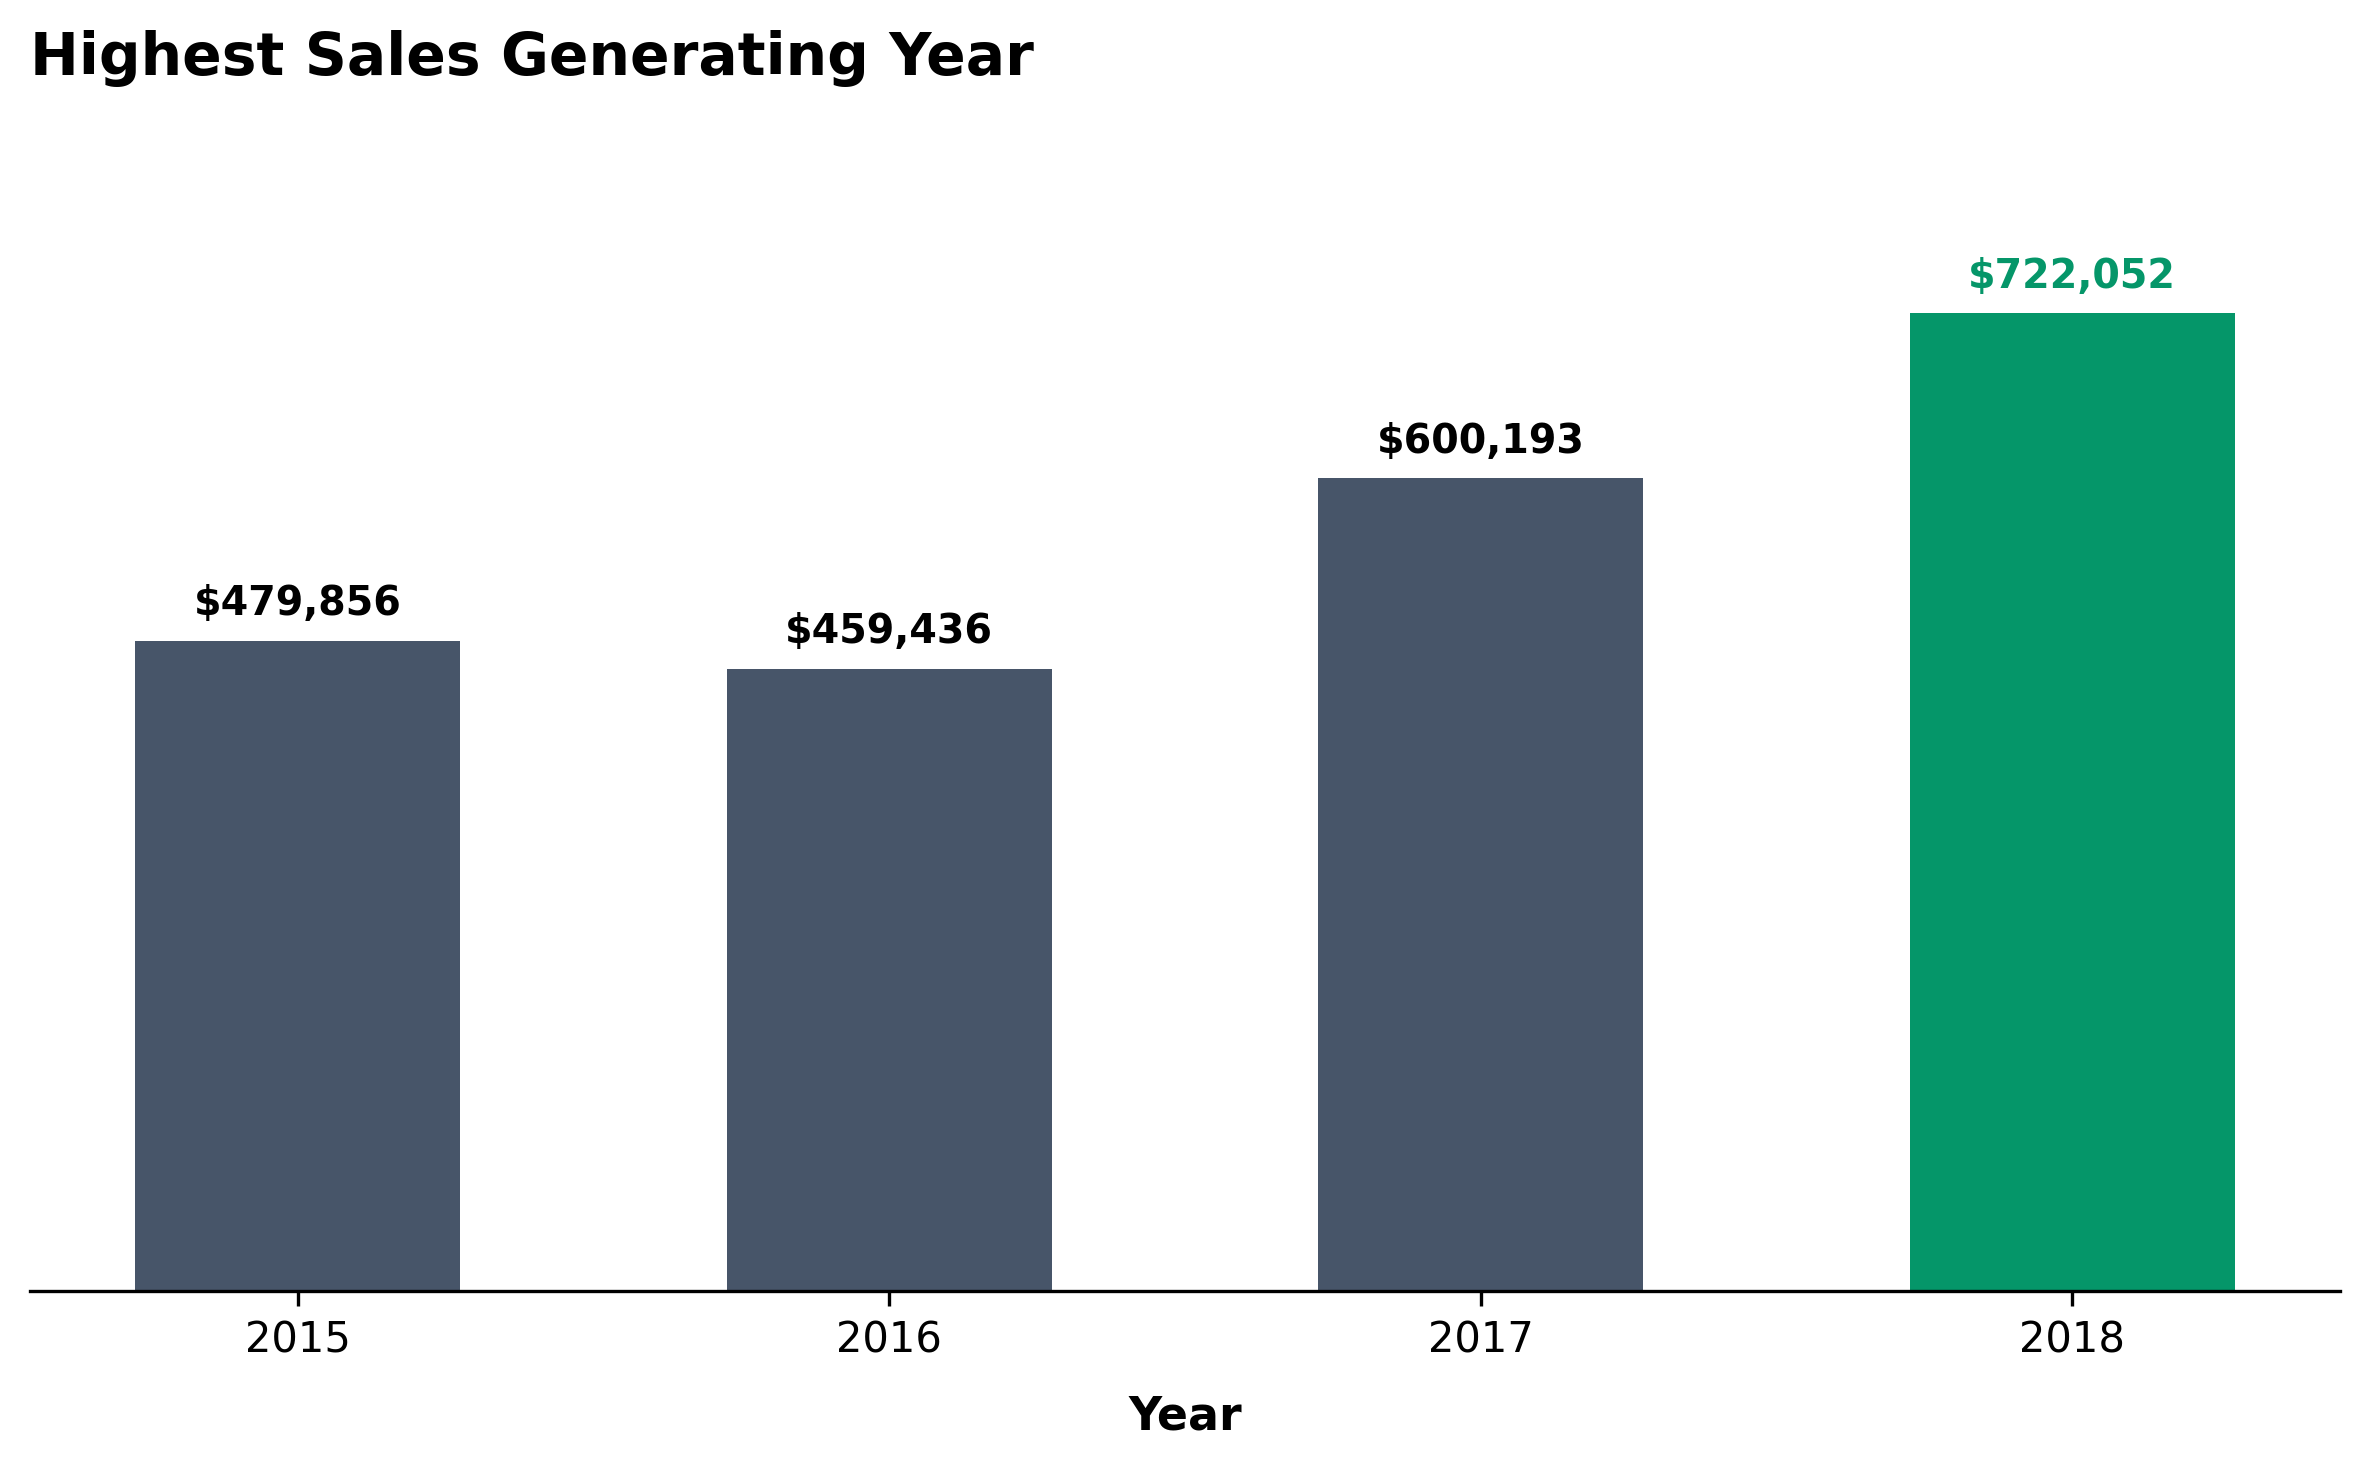

In [2]:
# 1. Groupby Yearly Data
yearly_sales = df.groupby(df["Order_Date"].dt.year)["Sales"].sum()

# 2. Setup Figure
fig, ax = plt.subplots(figsize=(8, 5), dpi=300)

# 3. Dynamic Highlight Colors (Top year = Emerald Green, Rest = Slate Grey)
max_val = yearly_sales.max()
bar_colors = ["#059669" if val == max_val else "#475569" for val in yearly_sales.values]

# 4. Bar Plot
bars = ax.bar(
    yearly_sales.index.astype(str), # Convert years to strings for discrete year bars
    yearly_sales.values,
    color=bar_colors,
    width=0.55
)

# 5. Bar Labels
ax.bar_label(
    bars,
    labels=[f"${x:,.0f}" for x in yearly_sales.values],
    padding=4,
    fontsize=9.5,
    fontweight="bold"
)

# Highlight Top Year's Text Label
for text, val in zip(ax.texts, yearly_sales.values):
    if val == max_val:
        text.set_color("#059669")

# 6. Spines & Cleanliness
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.get_yaxis().set_visible(False) # The y-axis is redundant because value labels are displayed above the bars

ax.set_ylim(0, max_val * 1.18)

# 7. Title & Labels
plt.title("Highest Sales Generating Year", fontsize=14, fontweight="bold", pad=15, loc="left")
plt.xlabel("Year", fontsize=11, fontweight="bold", labelpad=8)

# 8. Save with a separate file name to avoid overwriting other charts
plt.tight_layout()
plt.savefig(
    "../reports/charts/highest_sales_year.png", # Unique file name
    dpi=300,
    bbox_inches="tight"
)

plt.show()

> + Year-over-year growth %

In [ ]:
# Calculate the year-over-year percentage growth in sales
yearly_growth = yearly_sales.pct_change() * 100
print(yearly_growth)

Order_Date
2015          NaN
2016    -4.255484
2017    30.636812
2018    20.303396
Name: Sales, dtype: float64


> + Monthly Sales Trend

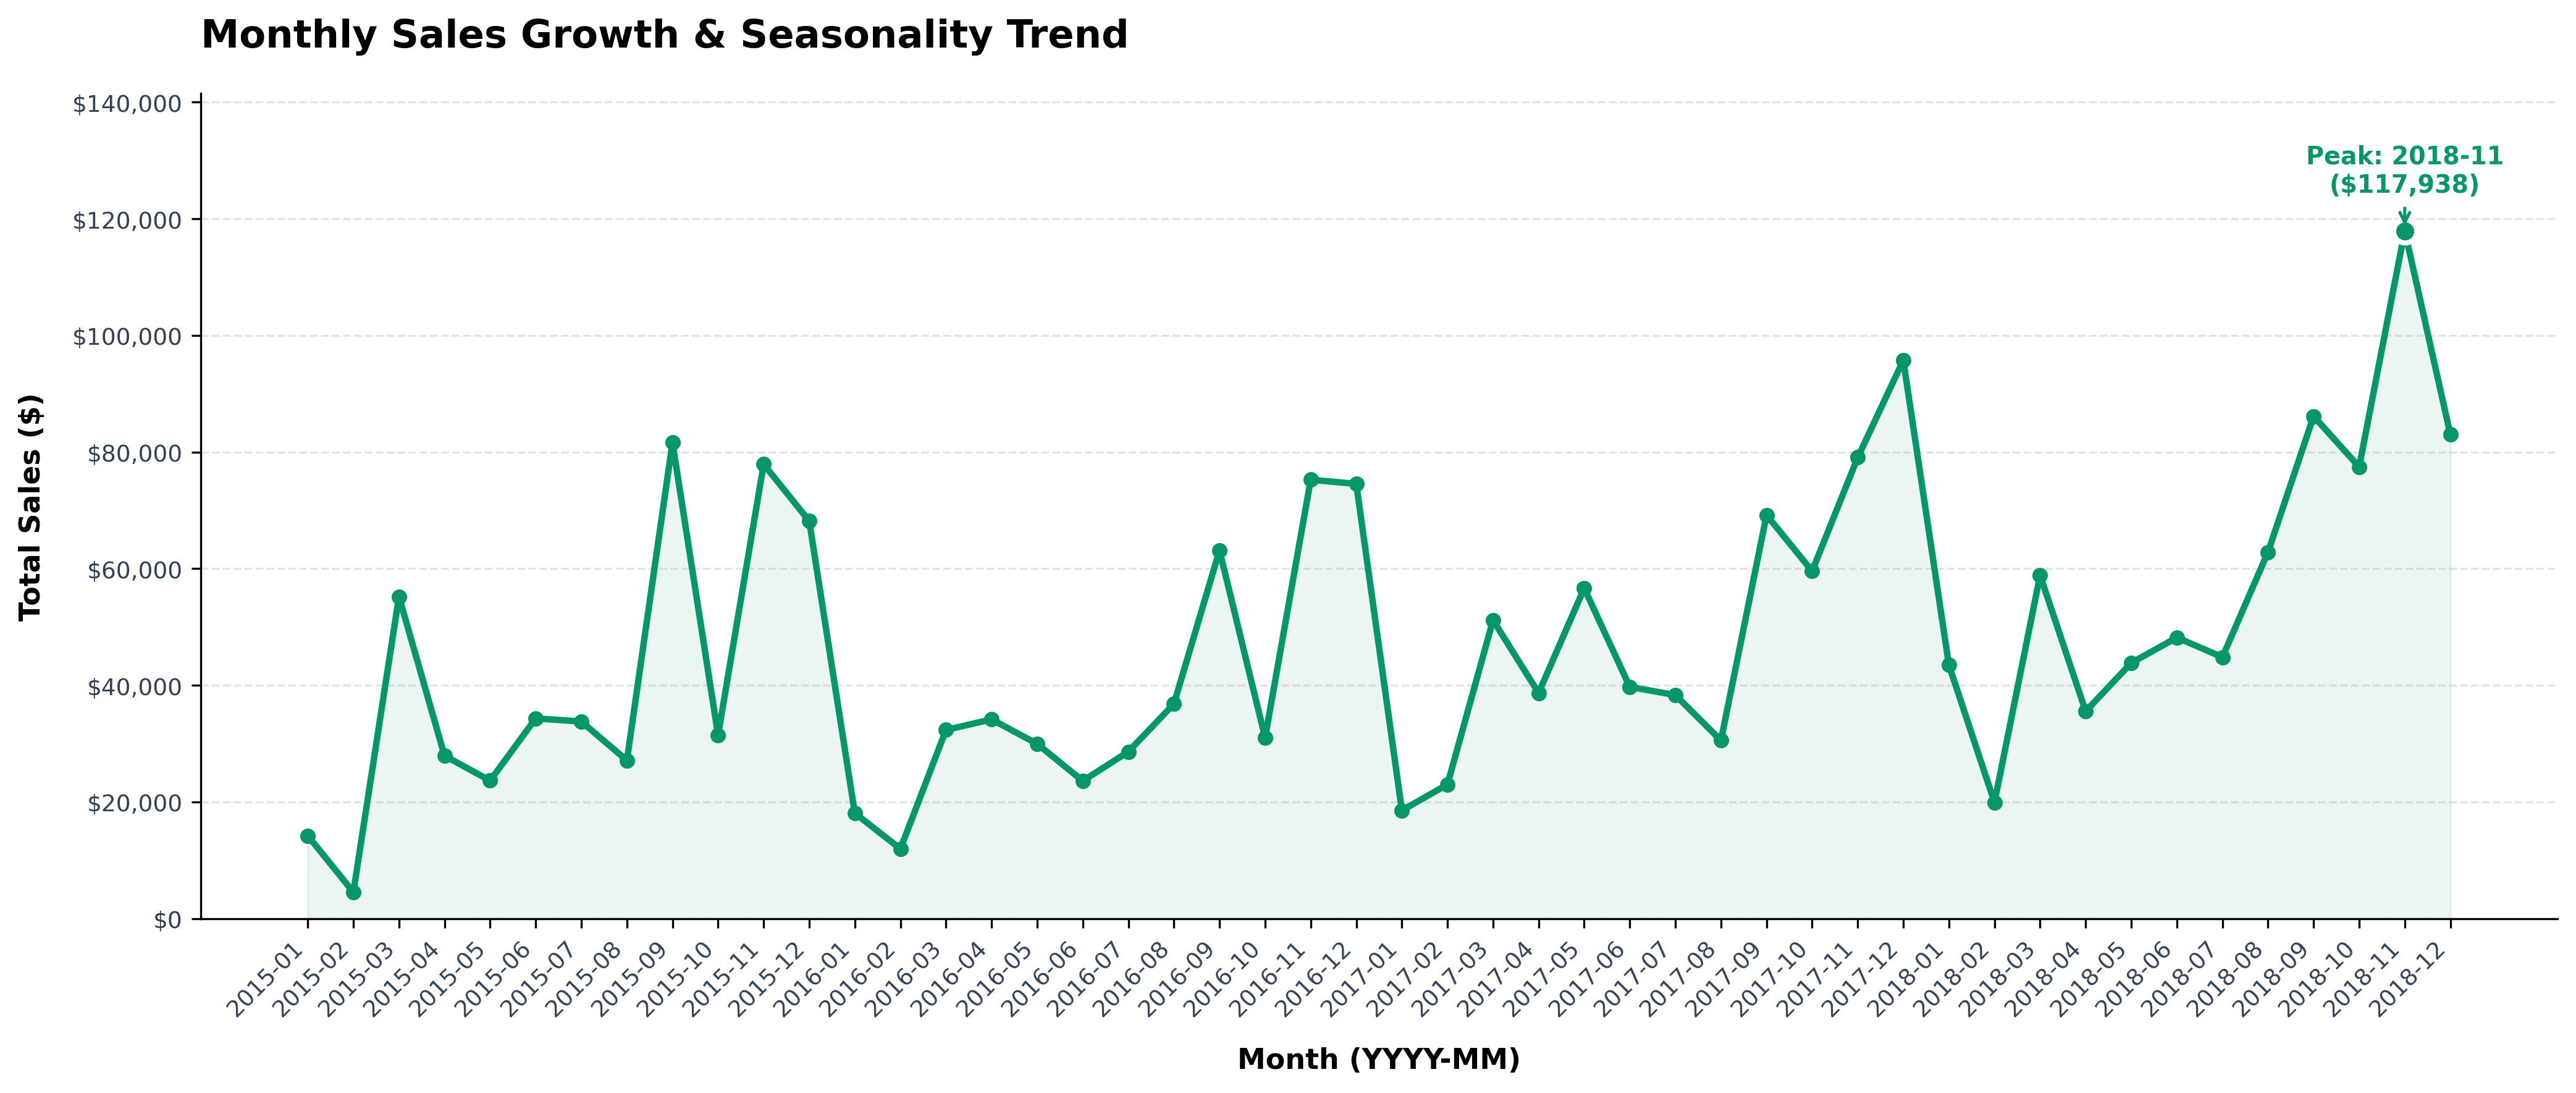

In [3]:
# 1. Groupby Monthly Data
monthly_sales = (
    df.groupby(df["Order_Date"].dt.to_period("M"))["Sales"]
    .sum()
)

# Convert the index to strings for clean categorical plotting
monthly_sales.index = monthly_sales.index.astype(str)

# Extract the peak month for highlighting
max_month = monthly_sales.idxmax()
max_sales = monthly_sales.max()

# 2. Setup Figure & Line Plot
fig, ax = plt.subplots(figsize=(14, 6), dpi=300)

# Line with Marker
ax.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o",
    markersize=5,
    color="#059669", # Emerald Green
    linewidth=2.5,
    label="Monthly Revenue"
)

# Slight gradient/fill underneath for visual depth
ax.fill_between(
    monthly_sales.index,
    monthly_sales.values,
    color="#059669",
    alpha=0.08
)

# 3. Highlight Top Peak Month
ax.plot(max_month, max_sales, marker="o", markersize=9, color="#059669", markeredgecolor="white", markeredgewidth=2)

ax.annotate(
    f"Peak: {max_month}\n(${max_sales:,.0f})",
    xy=(max_month, max_sales),
    xytext=(0, 15),
    textcoords="offset points",
    ha="center",
    fontsize=9.5,
    fontweight="bold",
    color="#059669",
    arrowprops=dict(arrowstyle="->", color="#059669", lw=1.2)
)

# 4. Spines & Axes Cleanliness
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Currency formatting for Y-axis
ax.yaxis.set_major_formatter("${x:,.0f}")
ax.set_ylim(0, max_sales * 1.2)

# X-Axis Ticks Formatting (Reduce clutter if many months exist)
plt.xticks(rotation=45, ha="right", fontsize=9, color="#334155")
plt.yticks(fontsize=9, color="#334155")

# 5. Title & Labels
plt.title("Monthly Sales Growth & Seasonality Trend", fontsize=15, fontweight="bold", pad=18, loc="left")
plt.xlabel("Month (YYYY-MM)", fontsize=11, fontweight="bold", labelpad=10)
plt.ylabel("Total Sales ($)", fontsize=11, fontweight="bold", labelpad=10)

# Subtle Grid
plt.grid(axis="y", linestyle="--", alpha=0.35)

# 6. Save & Display
plt.tight_layout()
plt.savefig(
    "../reports/charts/monthly_sales_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

> + Seasonality Check — Month-wise Pattern

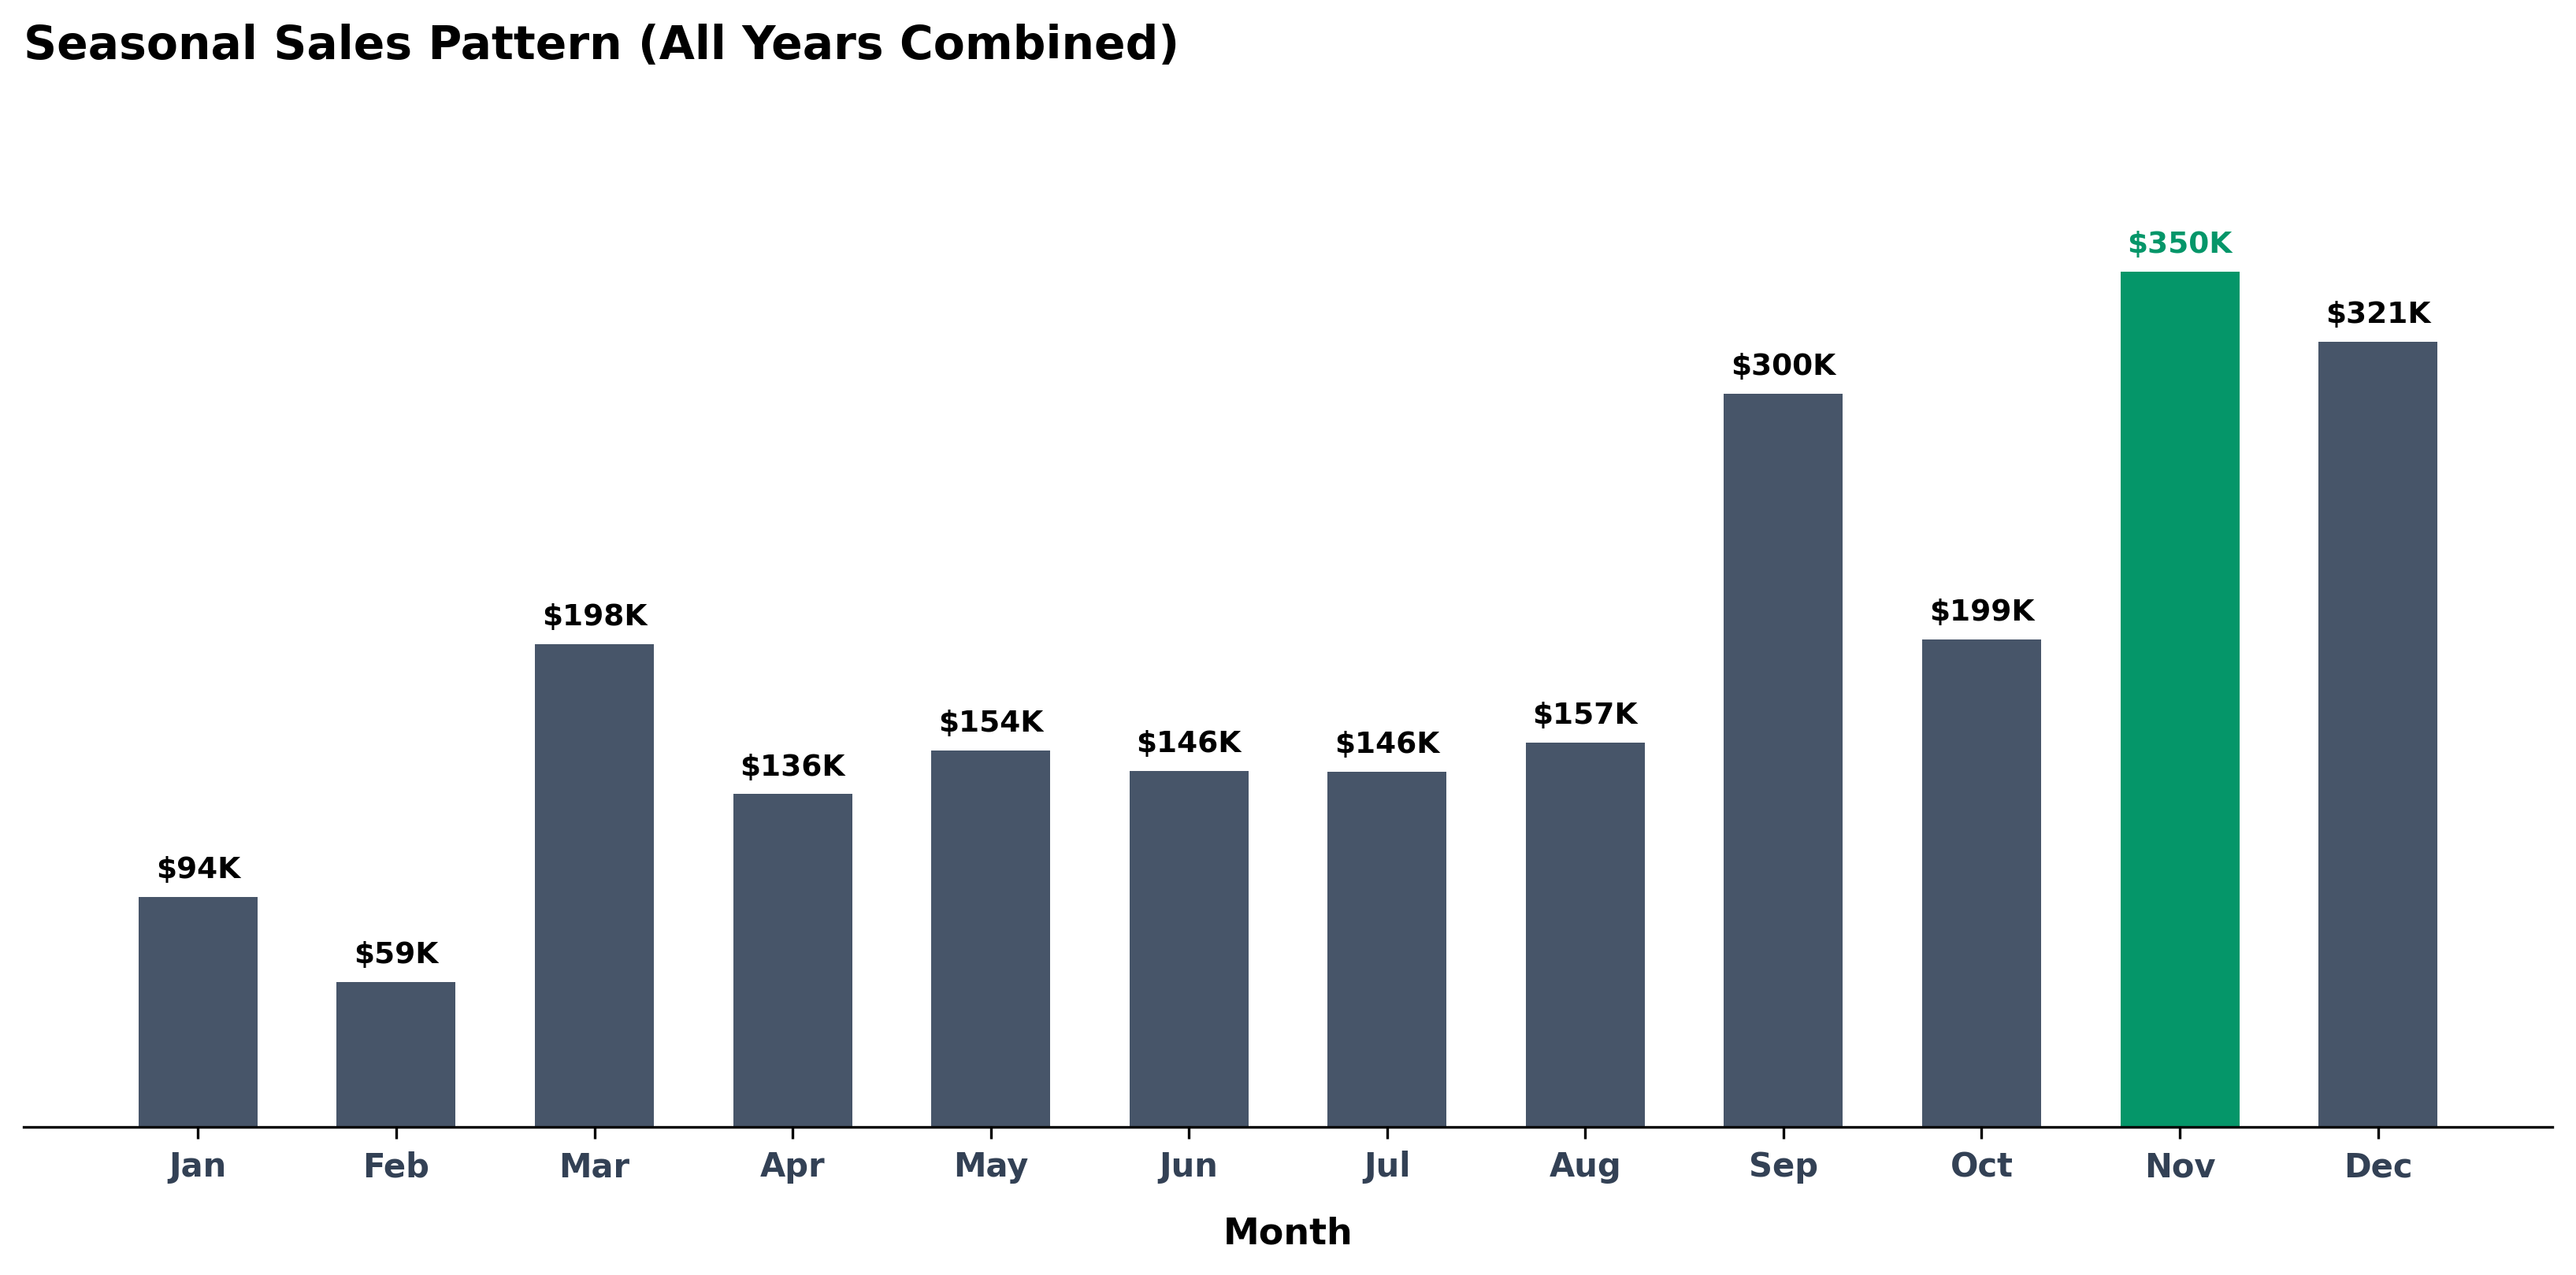

In [4]:
# 1. Extract month names & Aggregate
df["Order_Month"] = df["Order_Date"].dt.month_name()
seasonal_sales = df.groupby("Order_Month")["Sales"].sum()

# Reindex chronologically from January to December
month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]
seasonal_sales = seasonal_sales.reindex(month_order)

# Short month labels (Jan, Feb, Mar...) for clean X-axis display
short_months = [m[:3] for m in month_order]

# 2. Dynamic Highlight Colors (Max Month = Emerald Green, Rest = Slate)
max_val = seasonal_sales.max()
bar_colors = ["#059669" if val == max_val else "#475569" for val in seasonal_sales.values]

# 3. Setup Figure & Bar Plot
fig, ax = plt.subplots(figsize=(11, 5.5), dpi=300)

bars = ax.bar(
    short_months,
    seasonal_sales.values,
    color=bar_colors,
    width=0.6,
    edgecolor="none"
)

# 4. Bar Labels (Currency Formatted)
ax.bar_label(
    bars,
    labels=[f"${x/1000:,.0f}K" if x >= 1000 else f"${x:,.0f}" for x in seasonal_sales.values],
    padding=4,
    fontsize=9,
    fontweight="bold"
)

# Highlight Top Month's Label Text
for text, val in zip(ax.texts, seasonal_sales.values):
    if val == max_val:
        text.set_color("#059669")

# 5. Spines & Axes Cleanliness
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.get_yaxis().set_visible(False) # Values are displayed above the bars, so the left axis is redundant

ax.set_ylim(0, max_val * 1.18)
plt.xticks(rotation=0, fontsize=10, fontweight="bold", color="#334155")

# 6. Title & Labels
plt.title("Seasonal Sales Pattern (All Years Combined)", fontsize=14, fontweight="bold", pad=18, loc="left")
plt.xlabel("Month", fontsize=11, fontweight="bold", labelpad=10)

# Minimal Grid
plt.grid(axis="y", linestyle="--", alpha=0.35)

# 7. Save & Display
plt.tight_layout()
plt.savefig(
    "../reports/charts/seasonal_pattern.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

> + Best & Worst Months (Overall) 

In [5]:
# Identify the best-performing and lowest-performing months
best_month = monthly_sales.idxmax()
best_value = monthly_sales.max()

worst_month = monthly_sales.idxmin()
worst_value = monthly_sales.min()

print(f"Best-performing month: {best_month}")
print(f"Sales: ${best_value:,.2f}\n")

print(f"Lowest-performing month: {worst_month}")
print(f"Sales: ${worst_value:,.2f}")

Best-performing month: 2018-11
Sales: $117,938.15

Lowest-performing month: 2015-02
Sales: $4,519.89


> + Heatmap — Year vs Month

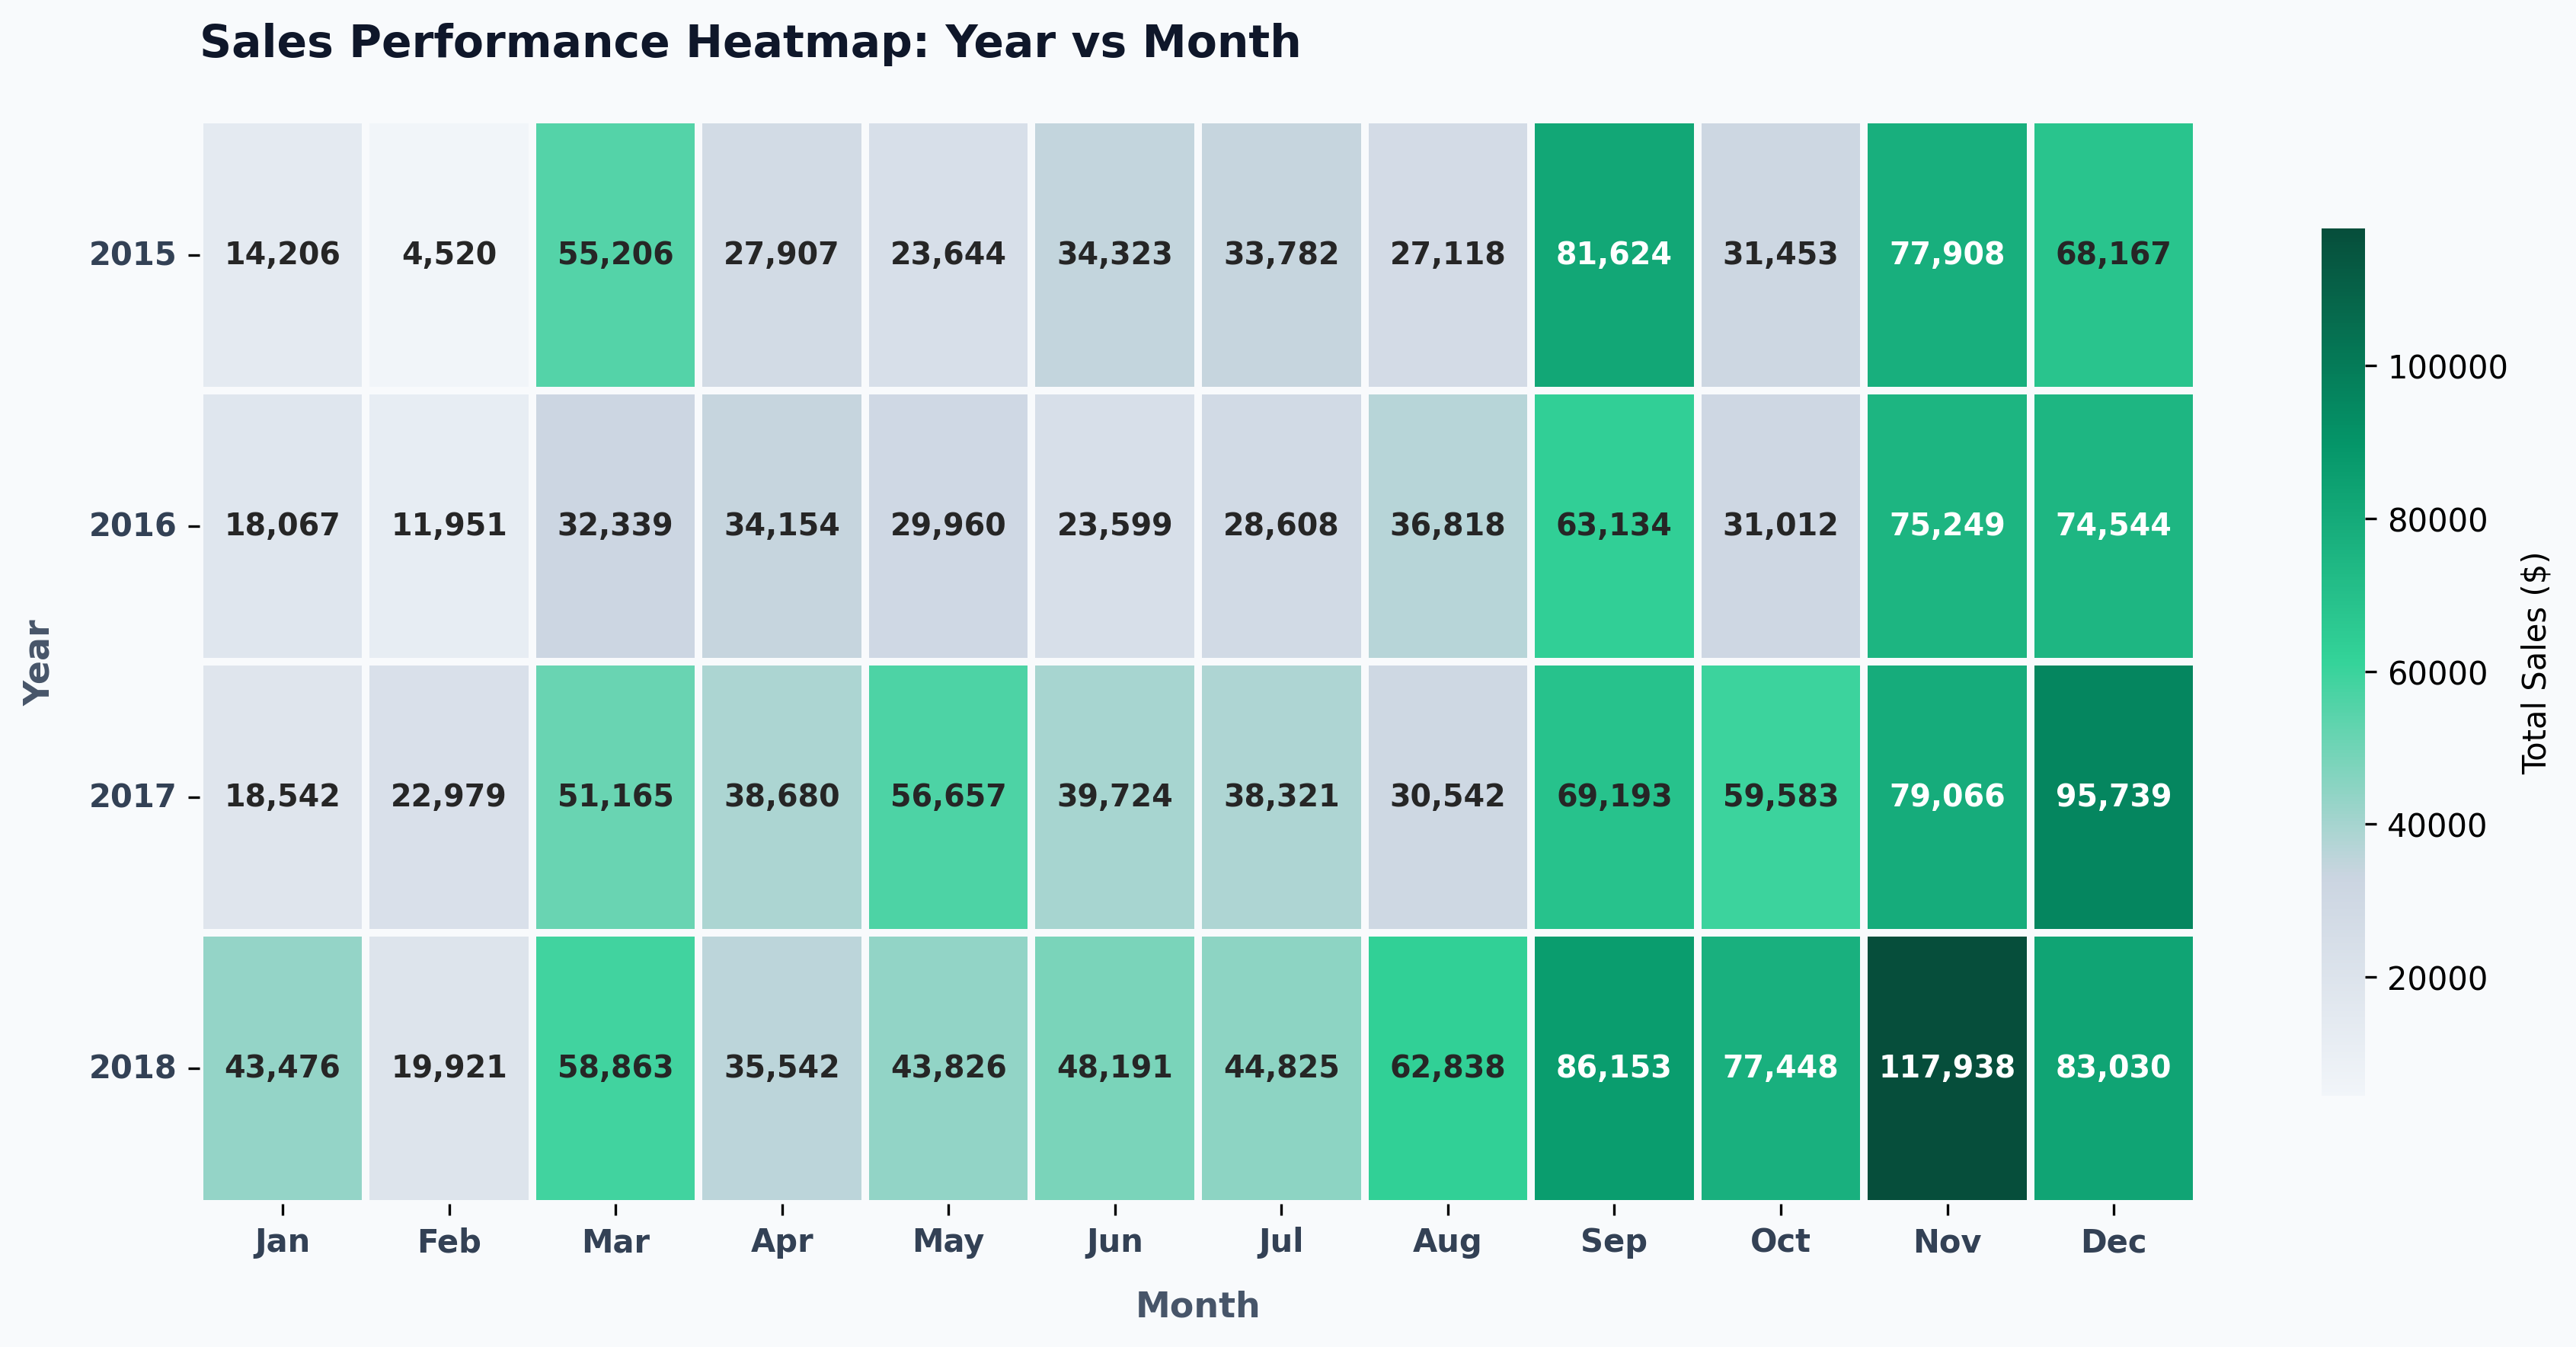

In [ ]:
# Import LinearSegmentedColormap to create a custom color gradient
from matplotlib.colors import LinearSegmentedColormap

# 1. Feature Engineering
df["Year"] = df["Order_Date"].dt.year
df["Month"] = df["Order_Date"].dt.month

# 2. Pivot Table Aggregation
pivot = df.pivot_table(
    index="Year",
    columns="Month",
    values="Sales",
    aggfunc="sum"
)

# Rename columns from 1..12 to Jan..Dec
month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
pivot.columns = [month_labels[m - 1] for m in pivot.columns]

# 3. Custom Executive Colormap (Light Slate-Grey -> Deep Emerald Green)
emerald_cmap = LinearSegmentedColormap.from_list(
    "executive_emerald", 
    ["#F1F5F9", "#CBD5E1", "#34D399", "#059669", "#064E3B"]
)

# 4. Setup Figure with Soft Card Background
fig, ax = plt.subplots(figsize=(12, 6), dpi=300)
fig.patch.set_facecolor("#F8FAFC")
ax.set_facecolor("#F8FAFC")

# 5. Seaborn Heatmap Plot
sns.heatmap(
    pivot,
    annot=True,
    fmt=",.0f",
    cmap=emerald_cmap,
    linewidths=2,             # Add clean separation between cells
    linecolor="#F8FAFC",      # Match grid lines with the card background
    cbar_kws={
        "label": "Total Sales ($)",
        "shrink": 0.8
    },
    annot_kws={
        "fontsize": 9.5,
        "fontweight": "bold"
    },
    ax=ax
)

# 6. Axes & Ticks Styling
plt.title(
    "Sales Performance Heatmap: Year vs Month", 
    fontsize=14, 
    fontweight="bold", 
    color="#0F172A",
    pad=20, 
    loc="left"
)
plt.xlabel("Month", fontsize=11, fontweight="bold", color="#475569", labelpad=10)
plt.ylabel("Year", fontsize=11, fontweight="bold", color="#475569", labelpad=10)

plt.xticks(rotation=0, fontsize=10, fontweight="bold", color="#334155")
plt.yticks(rotation=0, fontsize=10, fontweight="bold", color="#334155")

# 7. Save & Display (Retaining Card Background)
plt.tight_layout()
plt.savefig(
    "../reports/charts/year_month_heatmap.png",
    dpi=300,
    facecolor=fig.get_facecolor(),
    bbox_inches="tight"
)

plt.show()

## 📈 Time Trend Analysis Summary

### Yearly Performance
- Best year: `2018` with sales = `$722,052.02`
- Sales growth trend: Overall increasing, despite a decline in 2016
- Year-over-year growth rates:
  - `2016`: `-4.26%`
  - `2017`: `+30.64%`
  - `2018`: `+20.30%`

### Monthly Performance
- Best-performing month overall: `November 2018` ($117,938.15)
- Lowest-performing month overall: `February 2015` ($4,519.89)

### Seasonality
- Strong months: `November`, `December`
- Weak months: `February`, `January`

### 💡 Business Insight
The business shows a clear seasonal pattern, with sales generally peaking
during November and December and performing weakest during January and
February. The business could use targeted promotions and discounts during
these weaker months to help smooth out revenue across the year.

Although sales declined by `4.26%` in 2016, the business recovered strongly
in subsequent years, growing by `30.64%` in 2017 and `20.30%` in 2018.
\
Overall, the business shows a healthy long-term growth trajectory.